🚀 Starting Training on cuda...
Epoch [1/50] | Time: 17.1s | D Loss: 0.6189 | G Loss: 13.1191 | Val PSNR: 16.97 dB | Val SSIM: 0.5207
Epoch [2/50] | Time: 15.5s | D Loss: 0.6437 | G Loss: 11.2756 | Val PSNR: 17.62 dB | Val SSIM: 0.5936
Epoch [3/50] | Time: 15.6s | D Loss: 0.4876 | G Loss: 11.5285 | Val PSNR: 17.34 dB | Val SSIM: 0.5893
Epoch [4/50] | Time: 15.9s | D Loss: 0.1630 | G Loss: 13.5014 | Val PSNR: 17.27 dB | Val SSIM: 0.5468
Epoch [5/50] | Time: 16.4s | D Loss: 0.3371 | G Loss: 12.3017 | Val PSNR: 17.08 dB | Val SSIM: 0.6001
Epoch [6/50] | Time: 16.6s | D Loss: 0.0768 | G Loss: 14.0263 | Val PSNR: 17.58 dB | Val SSIM: 0.5785
Epoch [7/50] | Time: 17.0s | D Loss: 0.0246 | G Loss: 15.1216 | Val PSNR: 17.76 dB | Val SSIM: 0.5986
Epoch [8/50] | Time: 17.4s | D Loss: 0.1633 | G Loss: 14.3950 | Val PSNR: 17.85 dB | Val SSIM: 0.6230
Epoch [9/50] | Time: 17.3s | D Loss: 0.1078 | G Loss: 14.1601 | Val PSNR: 18.07 dB | Val SSIM: 0.6359
Epoch [10/50] | Time: 17.1s | D Loss: 0.0624 | G Lo

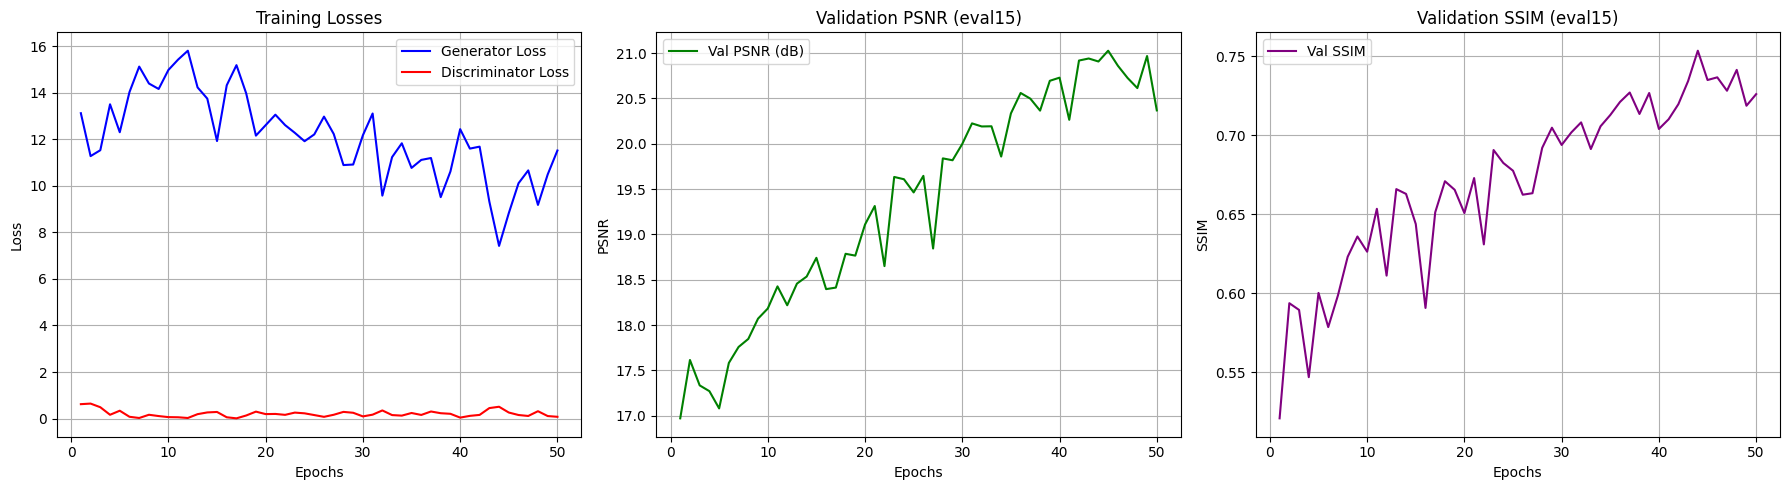

✅ Training complete. Check /kaggle/working/ for results, checkpoints, and graphs.


In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 1. HYPERPARAMETERS & PATHS
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
EPOCHS = 50
LR = 0.0002
BETA1 = 0.5
L1_LAMBDA = 100 
IMAGE_SIZE = 256 # Divisible by 32 for U-Net

# Kaggle Dataset Paths
TRAIN_LOW_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/low"
TRAIN_HIGH_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/high"
TEST_LOW_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/low"
TEST_HIGH_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/high"

# Output Directories
os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/graphs", exist_ok=True)

# ==========================================
# 2. DATASET DEFINITION
# ==========================================
class LLIEDataset(Dataset):
    def __init__(self, low_dir, high_dir, transform=None):
        self.low_dir = low_dir
        self.high_dir = high_dir
        # Only load files that exist in both directories
        self.image_files = [f for f in os.listdir(low_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        low_img_path = os.path.join(self.low_dir, img_name)
        high_img_path = os.path.join(self.high_dir, img_name)

        low_img = Image.open(low_img_path).convert("RGB")
        high_img = Image.open(high_img_path).convert("RGB")

        if self.transform:
            low_img = self.transform(low_img)
            high_img = self.transform(high_img)

        return low_img, high_img

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(), # Scales to [0, 1]
])

train_dataset = LLIEDataset(TRAIN_LOW_DIR, TRAIN_HIGH_DIR, transform=transform)
test_dataset = LLIEDataset(TEST_LOW_DIR, TEST_HIGH_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

# ==========================================
# 3. ARCHITECTURE: U-NET GENERATOR
# ==========================================
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 256)
        self.up5 = UNetUp(512, 128)
        self.up6 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Sigmoid() # Outputs [0, 1]
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        
        u1 = self.up1(d7, d6)
        u2 = self.up2(u1, d5)
        u3 = self.up3(u2, d4)
        u4 = self.up4(u3, d3)
        u5 = self.up5(u4, d2)
        u6 = self.up6(u5, d1)
        return self.final(u6)

# ==========================================
# 4. ARCHITECTURE: PATCHGAN DISCRIMINATOR
# ==========================================
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

# ==========================================
# 5. METRICS CALCULATION
# ==========================================
def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100.0
    return 20 * torch.log10(1.0 / torch.sqrt(mse)).item()

def calculate_ssim(img1, img2):
    img1_np = img1.cpu().detach().numpy().transpose(1, 2, 0)
    img2_np = img2.cpu().detach().numpy().transpose(1, 2, 0)
    return ssim(img1_np, img2_np, data_range=1.0, channel_axis=-1)

# ==========================================
# 6. TRAINING & EVALUATION LOOP
# ==========================================
def train_and_evaluate():
    generator = Generator().to(DEVICE)
    discriminator = Discriminator().to(DEVICE)

    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_pixelwise = nn.L1Loss()

    optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, 0.999))

    history = {'G_loss': [], 'D_loss': [], 'val_PSNR': [], 'val_SSIM': []}

    print(f"🚀 Starting Training on {DEVICE}...")
    for epoch in range(EPOCHS):
        start_time = time.time()
        g_loss_epoch, d_loss_epoch = 0.0, 0.0
        
        # --- TRAINING ---
        generator.train()
        discriminator.train()
        
        for i, (low_img, high_img) in enumerate(train_loader):
            low_img = low_img.to(DEVICE)
            high_img = high_img.to(DEVICE)

            valid = torch.ones((low_img.size(0), 1, IMAGE_SIZE//16, IMAGE_SIZE//16), device=DEVICE)
            fake = torch.zeros((low_img.size(0), 1, IMAGE_SIZE//16, IMAGE_SIZE//16), device=DEVICE)

            # Train Generator
            optimizer_G.zero_grad()
            gen_high = generator(low_img)
            
            pred_fake = discriminator(gen_high, low_img)
            loss_GAN = criterion_GAN(pred_fake, valid)
            loss_pixel = criterion_pixelwise(gen_high, high_img)
            
            loss_G = loss_GAN + (L1_LAMBDA * loss_pixel)
            loss_G.backward()
            optimizer_G.step()

            # Train Discriminator
            optimizer_D.zero_grad()
            pred_real = discriminator(high_img, low_img)
            loss_real = criterion_GAN(pred_real, valid)
            
            pred_fake = discriminator(gen_high.detach(), low_img)
            loss_fake = criterion_GAN(pred_fake, fake)
            
            loss_D = 0.5 * (loss_real + loss_fake)
            loss_D.backward()
            optimizer_D.step()

            g_loss_epoch += loss_G.item()
            d_loss_epoch += loss_D.item()

        # --- VALIDATION (eval15) ---
        generator.eval()
        val_psnr, val_ssim = 0.0, 0.0
        
        with torch.no_grad():
            for val_idx, (val_low, val_high) in enumerate(test_loader):
                val_low = val_low.to(DEVICE)
                val_high = val_high.to(DEVICE)
                
                val_gen = generator(val_low)
                
                val_psnr += calculate_psnr(val_gen, val_high)
                val_ssim += calculate_ssim(val_gen[0], val_high[0])
                
                # Save the first validation image of the batch periodically
                if val_idx == 0 and (epoch + 1) % 5 == 0:
                    comparison = torch.cat((val_low.data, val_gen.data, val_high.data), -2)
                    save_image(comparison, f"/kaggle/working/results/eval_epoch_{epoch+1}.png", normalize=False)

        # Calculate averages
        batches = len(train_loader)
        val_batches = len(test_loader)
        
        avg_g_loss = g_loss_epoch / batches
        avg_d_loss = d_loss_epoch / batches
        avg_psnr = val_psnr / val_batches
        avg_ssim = val_ssim / val_batches
        
        history['G_loss'].append(avg_g_loss)
        history['D_loss'].append(avg_d_loss)
        history['val_PSNR'].append(avg_psnr)
        history['val_SSIM'].append(avg_ssim)

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Time: {time.time()-start_time:.1f}s | "
              f"D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f} | "
              f"Val PSNR: {avg_psnr:.2f} dB | Val SSIM: {avg_ssim:.4f}")

        # Save Checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save(generator.state_dict(), f"/kaggle/working/checkpoints/gen_epoch_{epoch+1}.pth")

    return history

# ==========================================
# 7. PLOTTING GRAPHS
# ==========================================
def plot_and_save_metrics(history):
    epochs = range(1, len(history['G_loss']) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Losses
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['G_loss'], label='Generator Loss', color='blue')
    plt.plot(epochs, history['D_loss'], label='Discriminator Loss', color='red')
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot PSNR
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_PSNR'], label='Val PSNR (dB)', color='green')
    plt.title('Validation PSNR (eval15)')
    plt.xlabel('Epochs')
    plt.ylabel('PSNR')
    plt.legend()
    plt.grid(True)

    # Plot SSIM
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_SSIM'], label='Val SSIM', color='purple')
    plt.title('Validation SSIM (eval15)')
    plt.xlabel('Epochs')
    plt.ylabel('SSIM')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/graphs/training_metrics.png")
    plt.show()

# ==========================================
# 8. EXECUTE
# ==========================================
if __name__ == "__main__":
    metrics_history = train_and_evaluate()
    plot_and_save_metrics(metrics_history)
    print("✅ Training complete. Check /kaggle/working/ for results, checkpoints, and graphs.")